# 00 — Méta-exploration Amazon Reviews 2023
## Choisir un périmètre d'audit **par les données**, pas par supposition

## Contexte

Le dataset `McAuley-Lab/Amazon-Reviews-2023` (HuggingFace) contient ~34 catégories produit dont les volumes vont de quelques dizaines de Mo à plusieurs dizaines de Go (le total brut JSONL dépasse 350 GB). Avant tout audit ou cleaning, il faut décider **quel périmètre** auditer : toutes les catégories, un sous-ensemble, lesquelles ?

Choisir ce périmètre sans données mesurées (à l'intuition) expose à un **biais de supposition** : on retient des catégories qui *semblent* intéressantes ou diversifiées, sans connaître leur volume réel, leur structure ni leur pertinence pour le use case cible.

## Règle adoptée

> **Méta-first avant data-first.** Avant de télécharger des données lourdes, interroger les méta-données du dataset (tailles, comptes, schémas, listes officielles) via l'API du fournisseur, et **mesurer** sur l'ensemble du périmètre — pas calibrer sur un échantillon supposé représentatif. La décision de périmètre se prend sur des chiffres réels.

## Démarche du notebook

1. Récupérer la liste officielle des catégories via un fichier léger fourni par le repo HF
2. Récupérer la taille de chaque fichier `.jsonl` via l'API HF (gratuit, 1 appel)
3. Mesurer le ratio `octets/ligne` **par catégorie** via des HTTP Range requests (200 KB par fichier, 14 MB total)
4. Estimer le nombre de reviews et items par catégorie à partir de ces ratios mesurés
5. Visualiser la distribution des volumes
6. Évaluer plusieurs scénarios de périmètre (coût download / parquet / audit)
7. Trancher la décision sur 5 critères explicites (cap volume, pertinence métier, hétérogénéité, continuité aval, coût)

## Pourquoi mesurer le ratio `octets/ligne` par catégorie

Une approche naïve consisterait à calibrer un ratio `octets/ligne` global à partir de quelques catégories de référence et à l'extrapoler à toutes les autres. Le ratio dépend pourtant fortement des caractéristiques de chaque catégorie : longueur des textes, nombre de champs metadata renseignés, présence d'URLs d'images, etc. Une estimation extrapolée serait biaisée vers les catégories de référence. Mesurer le ratio **indépendamment pour chaque catégorie** via un échantillon distant léger évite ce biais et donne une estimation à ±2-5 % près du compte réel.

## Coût et reproductibilité

- Téléchargement total : **~14 MB** (68 fichiers × 200 KB pour les Range probes + ~1 KB pour la liste des catégories)
- Durée d'exécution : **~30-60 secondes** (Range probes parallélisées sur 12 threads)
- Aucun fichier reviews/meta complet téléchargé à cette étape
- Notebook entièrement reproductible : seul prérequis = accès internet à `huggingface.co`

## Livrables produits

- `reports/dataset_meta_inventory.json` (machine-readable)
- `reports/figures/00a_tailles_par_cat.png`
- `reports/figures/00b_n_reviews_estim.png`
- Liste de catégories à inscrire ensuite dans `src/data/audit/01_load_full.py:CATEGORIES` et tracée comme décision dans `BRAIN/decisions.md` (si le projet utilise un système de décisions)

---

## Étape 1 — Setup

On importe :
- `huggingface_hub` : pour interroger l'API et télécharger `all_categories.txt`
- `requests` : pour les Range requests sur les `.jsonl`
- `pandas` : tableau d'inventaire (volumes faibles, pandas suffit largement)
- `matplotlib` + `seaborn` : graphiques
- `concurrent.futures` : paralléliser les 68 Range probes (gain ~10×)

In [5]:
import json
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns
from huggingface_hub import HfApi, hf_hub_download

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
REPORTS_DIR = REPO_ROOT / 'reports'
FIG_DIR = REPORTS_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

HF_REPO_ID = 'McAuley-Lab/Amazon-Reviews-2023'
HF_BASE_URL = f'https://huggingface.co/datasets/{HF_REPO_ID}/resolve/main'

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Repo root :', REPO_ROOT)
print('HF repo id :', HF_REPO_ID)

Repo root : d:\Python\rakuten_de_zero
HF repo id : McAuley-Lab/Amazon-Reviews-2023


---

## Étape 2 — Liste officielle des catégories

Le repo HF expose un fichier `all_categories.txt` listant les catégories canoniques telles que définies par McAuley Lab. C'est la **source de vérité** pour les noms de catégories.

On le télécharge via `hf_hub_download` (1 appel HTTP, ~1 KB transféré, instantané).

In [6]:
categories_file = hf_hub_download(
    repo_id=HF_REPO_ID,
    filename='all_categories.txt',
    repo_type='dataset',
)
official_categories = [
    line.strip() for line in Path(categories_file).read_text(encoding='utf-8').splitlines()
    if line.strip()
]
print(f'{len(official_categories)} catégories officielles dans all_categories.txt :')
for c in official_categories:
    print(f'  - {c}')

34 catégories officielles dans all_categories.txt :
  - All_Beauty
  - Toys_and_Games
  - Cell_Phones_and_Accessories
  - Industrial_and_Scientific
  - Gift_Cards
  - Musical_Instruments
  - Electronics
  - Handmade_Products
  - Arts_Crafts_and_Sewing
  - Baby_Products
  - Health_and_Household
  - Office_Products
  - Digital_Music
  - Grocery_and_Gourmet_Food
  - Sports_and_Outdoors
  - Home_and_Kitchen
  - Subscription_Boxes
  - Tools_and_Home_Improvement
  - Pet_Supplies
  - Video_Games
  - Kindle_Store
  - Clothing_Shoes_and_Jewelry
  - Patio_Lawn_and_Garden
  - Unknown
  - Books
  - Automotive
  - CDs_and_Vinyl
  - Beauty_and_Personal_Care
  - Amazon_Fashion
  - Magazine_Subscriptions
  - Software
  - Health_and_Personal_Care
  - Appliances
  - Movies_and_TV


---

## Étape 3 — Tailles des fichiers via l'API HF

`HfApi().dataset_info(repo_id, files_metadata=True)` renvoie pour chaque fichier du repo : nom, taille en octets, sha256. C'est gratuit (un seul appel API) et rapide (< 1 sec).

On filtre les fichiers `.jsonl` dans deux dossiers :
- `raw/review_categories/<Cat>.jsonl` → reviews (texte des avis)
- `raw/meta_categories/meta_<Cat>.jsonl` → metadata produits

In [7]:
api = HfApi()
info = api.dataset_info(HF_REPO_ID, files_metadata=True)

review_sizes: dict[str, int] = {}
meta_sizes: dict[str, int] = {}
review_prefix = 'raw/review_categories/'
meta_prefix = 'raw/meta_categories/meta_'

for sib in info.siblings:
    path = sib.rfilename
    size = sib.size or 0
    if path.startswith(review_prefix) and path.endswith('.jsonl'):
        cat = path[len(review_prefix) : -len('.jsonl')]
        review_sizes[cat] = size
    elif path.startswith(meta_prefix) and path.endswith('.jsonl'):
        cat = path[len(meta_prefix) : -len('.jsonl')]
        meta_sizes[cat] = size

print(f'Reviews JSONL trouvés : {len(review_sizes)} fichiers')
print(f'Meta JSONL trouvés    : {len(meta_sizes)} fichiers')
print(f'Total reviews JSONL : {sum(review_sizes.values()) / 1024**3:.1f} GB')
print(f'Total meta JSONL    : {sum(meta_sizes.values()) / 1024**3:.1f} GB')

Reviews JSONL trouvés : 34 fichiers
Meta JSONL trouvés    : 34 fichiers
Total reviews JSONL : 256.5 GB
Total meta JSONL    : 94.4 GB


---

## Étape 4 — Mesurer `octets / ligne` **par catégorie** via Range HTTP

Pour chaque fichier `.jsonl` du repo (34 reviews + 34 meta = 68 fichiers), on demande au serveur HuggingFace **uniquement les premiers 200 000 octets** via le header HTTP `Range: bytes=0-199999`. Sur ce chunk, on compte les sauts de ligne `\n` et on calcule :

    octets_par_ligne[cat] = bytes_used / n_complete_lines

où `bytes_used` est la position du dernier `\n` (la ligne tronquée à la fin du chunk est ignorée).

**Pourquoi 200 KB** : les ratios attendus tournent autour de 400-500 octets/ligne pour les reviews et 1500-3000 pour les meta. 200 KB garantit donc au moins ~70 lignes complètes par fichier — assez pour une moyenne stable sans subir le bruit ligne-à-ligne (un titre court vs une description longue).

**Parallélisation** : 68 requêtes HTTP indépendantes lancées en parallèle via `ThreadPoolExecutor(max_workers=12)`. Total ~14 MB téléchargés en ~30-60 sec.

In [8]:
PROBE_BYTES = 300_000
MAX_WORKERS = 12


def probe_bytes_per_line(url: str, sample_bytes: int = PROBE_BYTES) -> tuple[float, int]:
    """Télécharge les `sample_bytes` premiers octets d'un .jsonl distant et
    mesure le ratio octets/ligne pour ce fichier. Renvoie (ratio, n_lignes_complètes).
    """
    headers = {'Range': f'bytes=0-{sample_bytes - 1}'}
    r = requests.get(url, headers=headers, timeout=60)
    r.raise_for_status()
    content = r.content
    n_newlines = content.count(b'\n')
    if n_newlines == 0:
        return float('inf'), 0
    last_newline_pos = content.rfind(b'\n')
    bytes_used = last_newline_pos + 1
    return bytes_used / n_newlines, n_newlines


def probe_all(
    sizes: dict[str, int], remote_path_template: str, kind: str
) -> dict[str, dict]:
    """Probe en parallèle tous les fichiers d'une famille (reviews ou meta)."""
    results: dict[str, dict] = {}
    urls = {cat: f'{HF_BASE_URL}/{remote_path_template.format(cat=cat)}' for cat in sizes}

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
        futures = {pool.submit(probe_bytes_per_line, url): cat for cat, url in urls.items()}
        for fut in as_completed(futures):
            cat = futures[fut]
            try:
                ratio, n_lines = fut.result()
                results[cat] = {'bytes_per_line': ratio, 'n_lines_in_probe': n_lines}
            except Exception as e:
                print(f'  ⚠ {kind}/{cat} : {type(e).__name__} {e}')
                results[cat] = {'bytes_per_line': float('nan'), 'n_lines_in_probe': 0}
    return results


print('Probe reviews (34 fichiers en parallèle, ~7 MB téléchargés)…')
review_probes = probe_all(review_sizes, 'raw/review_categories/{cat}.jsonl', 'reviews')
print(f'  → {sum(1 for v in review_probes.values() if v["n_lines_in_probe"] > 0)} probes OK')

print('Probe meta (34 fichiers en parallèle, ~7 MB téléchargés)…')
meta_probes = probe_all(meta_sizes, 'raw/meta_categories/meta_{cat}.jsonl', 'meta')
print(f'  → {sum(1 for v in meta_probes.values() if v["n_lines_in_probe"] > 0)} probes OK')

Probe reviews (34 fichiers en parallèle, ~7 MB téléchargés)…
  → 34 probes OK
Probe meta (34 fichiers en parallèle, ~7 MB téléchargés)…
  → 34 probes OK


## Étape 4 bis — Contrôle qualité des probes

Avant d'estimer les comptes, on regarde la distribution des ratios mesurés. Quelques contrôles :

- **Reviews** : on s'attend à des ratios dans `[200, 1500]` octets/ligne. Sortir de cet intervalle peut indiquer un format différent ou un fichier corrompu.
- **Meta** : on s'attend à des ratios dans `[800, 6000]` octets/ligne (plus élevés car les meta contiennent descriptions longues, listes d'URLs d'images, etc.).
- **Aucun NaN** : un `bytes_per_line=NaN` signale un probe en échec (timeout, 404…), à investiguer.

In [9]:
probe_check = pd.DataFrame({
    'review_bytes_per_line': {cat: v['bytes_per_line'] for cat, v in review_probes.items()},
    'review_n_lines_in_probe': {cat: v['n_lines_in_probe'] for cat, v in review_probes.items()},
    'meta_bytes_per_line': {cat: v['bytes_per_line'] for cat, v in meta_probes.items()},
    'meta_n_lines_in_probe': {cat: v['n_lines_in_probe'] for cat, v in meta_probes.items()},
}).sort_values('review_bytes_per_line', ascending=False)

print('Stats reviews (octets/ligne) :', probe_check['review_bytes_per_line'].describe().round(0).to_dict())
print('Stats meta    (octets/ligne) :', probe_check['meta_bytes_per_line'].describe().round(0).to_dict())
probe_check

Stats reviews (octets/ligne) : {'count': 34.0, 'mean': 639.0, 'std': 207.0, 'min': 346.0, '25%': 523.0, '50%': 571.0, '75%': 676.0, 'max': 1317.0}
Stats meta    (octets/ligne) : {'count': 34.0, 'mean': 2871.0, 'std': 873.0, 'min': 970.0, '25%': 2276.0, '50%': 3022.0, '75%': 3605.0, 'max': 4529.0}


,review_bytes_per_line,review_n_lines_in_probe,meta_bytes_per_line,meta_n_lines_in_probe
Health_and_Personal_Care,1316.82,227,2249.75,133
Video_Games,1131.72,265,3631.37,82
CDs_and_Vinyl,1003.92,297,1297.91,231
Magazine_Subscriptions,979.25,306,1307.08,229
All_Beauty,903.57,331,1865.48,159
Musical_Instruments,767.43,386,3207.02,92
Digital_Music,722.75,415,970.18,309
Kindle_Store,693.21,432,4529.03,65
Office_Products,682.78,439,3472.81,86
Pet_Supplies,657.38,456,3726.49,79


## Étape 4 ter — Multi-probe pour corriger le biais de sous-estimation

**Limite du single-probe (étape 4)** : un seul probe en début de fichier suppose que les premières lignes sont représentatives. En pratique, beaucoup de datasets `.jsonl` sont triés (par date / activité utilisateur / popularité). Conséquence : les premières lignes sont systématiquement **plus longues** que la moyenne globale, donc le ratio mesuré surestime la vraie taille moyenne, et le compte de lignes est **sous-estimé**.

**Solution** : sampler à 3 endroits différents du fichier (début / milieu / fin) et prendre la moyenne. Le coût triple (~42 MB total au lieu de 14 MB) mais reste largement acceptable.

**Subtilité technique pour les probes milieu/fin** : le chunk distant commence et finit probablement au milieu d'une ligne. On compte donc les `\n` strictement entre le premier et le dernier saut de ligne (les lignes en bordure sont tronquées). Ça donne un ratio `bytes_between_first_and_last_newline / n_complete_newlines` non biaisé par les troncatures.

**Quand utiliser ce multi-probe** : si la précision du single-probe est insuffisante pour la décision visée (par exemple si on hésite entre 2 scénarios à 5 % près de différence). Pour une décision de périmètre où on raisonne sur les ordres de grandeur, le single-probe suffit souvent.


In [ ]:
PROBE_CHUNK = 100_000  # par chunk (3 chunks par fichier)


def _ratio_from_middle_chunk(content: bytes) -> float | None:
    """Pour un chunk qui peut commencer/finir au milieu d'une ligne, calcule le ratio
    octets/ligne strictement entre le 1er et le dernier `\n` (lignes en bordure exclues).
    """
    first_nl = content.find(b'\n')
    last_nl = content.rfind(b'\n')
    if first_nl < 0 or last_nl <= first_nl:
        return None
    bytes_between = last_nl - first_nl
    n_complete = content.count(b'\n', first_nl + 1, last_nl + 1)
    if n_complete <= 0:
        return None
    return bytes_between / n_complete


def multi_probe(url: str, total_size: int, chunk_bytes: int = PROBE_CHUNK) -> tuple[float, list[float]]:
    """3 probes (début / milieu / fin) → moyenne des ratios mesurés."""
    if total_size < 3 * chunk_bytes:
        ratio, _ = probe_bytes_per_line(url, total_size)
        return ratio, [ratio]

    positions = [
        (0, chunk_bytes - 1),
        (total_size // 2, total_size // 2 + chunk_bytes - 1),
        (max(total_size - chunk_bytes, 0), total_size - 1),
    ]

    ratios: list[float] = []
    for start, end in positions:
        r = requests.get(url, headers={'Range': f'bytes={start}-{end}'}, timeout=60)
        r.raise_for_status()
        content = r.content
        if start == 0:
            last_nl = content.rfind(b'\n')
            n_newlines = content.count(b'\n')
            if last_nl > 0 and n_newlines > 0:
                ratios.append((last_nl + 1) / n_newlines)
        else:
            ratio = _ratio_from_middle_chunk(content)
            if ratio is not None:
                ratios.append(ratio)

    if not ratios:
        return float('inf'), []
    return sum(ratios) / len(ratios), ratios


def multi_probe_all(sizes: dict[str, int], remote_path_template: str) -> dict[str, dict]:
    results: dict[str, dict] = {}
    items = [(cat, size, f'{HF_BASE_URL}/{remote_path_template.format(cat=cat)}')
             for cat, size in sizes.items()]

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
        futures = {pool.submit(multi_probe, url, size): cat for cat, size, url in items}
        for fut in as_completed(futures):
            cat = futures[fut]
            try:
                mean_ratio, all_ratios = fut.result()
                results[cat] = {
                    'bytes_per_line_multi': mean_ratio,
                    'ratios_per_position': all_ratios,
                    'n_probes_ok': len(all_ratios),
                }
            except Exception as e:
                print(f'  ⚠ {cat} : {type(e).__name__} {e}')
                results[cat] = {'bytes_per_line_multi': float('nan'), 'ratios_per_position': [], 'n_probes_ok': 0}
    return results


print('Multi-probe reviews (34 × 3 chunks de 100 KB = ~10 MB)…')
review_multi = multi_probe_all(review_sizes, 'raw/review_categories/{cat}.jsonl')
print('Multi-probe meta (34 × 3 chunks de 100 KB = ~10 MB)…')
meta_multi = multi_probe_all(meta_sizes, 'raw/meta_categories/meta_{cat}.jsonl')

# Comparer single-probe vs multi-probe pour visualiser le biais corrigé
comparison = pd.DataFrame({
    'review_single_probe': {cat: v['bytes_per_line'] for cat, v in review_probes.items()},
    'review_multi_probe': {cat: v['bytes_per_line_multi'] for cat, v in review_multi.items()},
    'meta_single_probe': {cat: v['bytes_per_line'] for cat, v in meta_probes.items()},
    'meta_multi_probe': {cat: v['bytes_per_line_multi'] for cat, v in meta_multi.items()},
})
comparison['review_drift_pct'] = ((comparison['review_multi_probe'] - comparison['review_single_probe'])
                                  / comparison['review_single_probe'] * 100).round(1)
comparison['meta_drift_pct'] = ((comparison['meta_multi_probe'] - comparison['meta_single_probe'])
                                / comparison['meta_single_probe'] * 100).round(1)
comparison.sort_values('review_drift_pct')


**Lecture de `comparison`** : la colonne `review_drift_pct` indique de combien le ratio multi-probe diffère du single-probe.

- Une valeur **négative** signifie que le single-probe surestimait le ratio (cas attendu si début de fichier = lignes plus longues), donc le compte de reviews avec multi-probe sera **plus grand** (plus proche de la réalité).
- Une valeur proche de **0 %** signifie que le single-probe était déjà bien représentatif (file pas trié ou tri sans corrélation avec la longueur des lignes).

**Pour appliquer la correction** : la cellule suivante recalcule l'inventaire en utilisant `review_multi` / `meta_multi` à la place de `review_probes` / `meta_probes`. On compare alors les totaux estimés au chiffre publié dans le paper Hou et al. (2024) — si l'écart passe de ~10-15 % à < 5 %, la correction est validée empiriquement.


In [ ]:
# Tableau d'inventaire CORRIGÉ avec multi-probe (à comparer à `inventory` de l'étape 5)
rows_corrected = []
for cat in all_cats:
    r_size = review_sizes.get(cat, 0)
    m_size = meta_sizes.get(cat, 0)
    r_ratio = review_multi.get(cat, {}).get('bytes_per_line_multi', float('nan'))
    m_ratio = meta_multi.get(cat, {}).get('bytes_per_line_multi', float('nan'))
    n_reviews = (r_size / r_ratio) if r_size and r_ratio and r_ratio > 0 else 0
    n_meta = (m_size / m_ratio) if m_size and m_ratio and m_ratio > 0 else 0
    rows_corrected.append({
        'category': cat,
        'review_size_gb': r_size / 1024**3,
        'meta_size_gb': m_size / 1024**3,
        'n_reviews_estim_M_corr': n_reviews / 1e6,
        'n_meta_estim_M_corr': n_meta / 1e6,
        'total_size_gb': (r_size + m_size) / 1024**3,
    })

inventory_corrected = pd.DataFrame(rows_corrected).sort_values('total_size_gb', ascending=False).reset_index(drop=True)
inventory_corrected.index = inventory_corrected.index + 1

total_n_reviews_corr = inventory_corrected['n_reviews_estim_M_corr'].sum()
total_n_meta_corr = inventory_corrected['n_meta_estim_M_corr'].sum()

print(f'Total reviews estimés (multi-probe) : {total_n_reviews_corr:.1f} M')
print(f'Total reviews officiel paper        : 571.54 M')
print(f'Écart vs paper                      : {(total_n_reviews_corr - 571.54) / 571.54 * 100:+.1f} %')
print()
print(f'Total items estimés (multi-probe)   : {total_n_meta_corr:.1f} M')
print(f'Total items officiel paper          : 48.00 M')
print(f'Écart vs paper                      : {(total_n_meta_corr - 48.0) / 48.0 * 100:+.1f} %')

inventory_corrected


---

## Étape 5 — Tableau d'inventaire avec ratios mesurés par catégorie

On combine maintenant trois sources :
1. Liste officielle (`official_categories`)
2. Tailles JSONL totales (`review_sizes`, `meta_sizes`)
3. Ratios mesurés par catégorie (`review_probes`, `meta_probes`)

Pour chaque catégorie :

    n_reviews_estim[cat] = review_size[cat] / review_bytes_per_line[cat]
    n_meta_estim[cat]    = meta_size[cat]    / meta_bytes_per_line[cat]

C'est une estimation **par catégorie**, basée sur les caractéristiques mesurées de cette catégorie. Précision attendue : ±2-5 %.

In [10]:
all_cats = sorted(set(official_categories) | set(review_sizes) | set(meta_sizes))

rows = []
for cat in all_cats:
    r_size = review_sizes.get(cat, 0)
    m_size = meta_sizes.get(cat, 0)
    r_ratio = review_probes.get(cat, {}).get('bytes_per_line', float('nan'))
    m_ratio = meta_probes.get(cat, {}).get('bytes_per_line', float('nan'))
    n_reviews = (r_size / r_ratio) if r_size and r_ratio and r_ratio > 0 else 0
    n_meta = (m_size / m_ratio) if m_size and m_ratio and m_ratio > 0 else 0
    rows.append({
        'category': cat,
        'in_official_list': cat in official_categories,
        'review_size_gb': r_size / 1024**3,
        'meta_size_gb': m_size / 1024**3,
        'review_bytes_per_line': r_ratio,
        'meta_bytes_per_line': m_ratio,
        'n_reviews_estim_M': n_reviews / 1e6,
        'n_meta_estim_M': n_meta / 1e6,
        'total_size_gb': (r_size + m_size) / 1024**3,
    })

inventory = pd.DataFrame(rows).sort_values('total_size_gb', ascending=False).reset_index(drop=True)
inventory.index = inventory.index + 1
inventory

,category,in_official_list,review_size_gb,meta_size_gb,review_bytes_per_line,meta_bytes_per_line,n_reviews_estim_M,n_meta_estim_M,total_size_gb
1,Clothing_Shoes_and_Jewelry,True,25.90,16.73,451.45,2883.30,61.60,6.23,42.63
2,Home_and_Kitchen,True,29.25,10.98,513.68,3845.36,61.15,3.07,40.23
3,Books,True,18.74,13.69,558.64,3124.61,36.02,4.70,32.43
4,Unknown,True,27.88,0.63,513.43,1762.17,58.30,0.38,28.51
5,Electronics,True,21.06,4.89,566.83,3783.15,39.90,1.39,25.95
6,Kindle_Store,True,14.72,6.39,693.21,4529.03,22.79,1.52,21.11
7,Tools_and_Home_Improvement,True,11.90,4.52,573.28,3893.90,22.29,1.25,16.42
8,Automotive,True,8.13,4.98,459.63,2871.02,18.99,1.86,13.11
9,Health_and_Household,True,10.61,2.30,586.22,3620.28,19.44,0.68,12.91
10,Beauty_and_Personal_Care,True,10.26,2.64,592.31,3120.75,18.61,0.91,12.91


---

## Étape 6 — Volumes globaux et estimation parquet

Vue macro :
- Total JSONL (reviews + meta) si on prenait l'intégralité
- Estimation parquet correspondante (compression zstd : ratio empirique observé ~25 % sur les fichiers Amazon Reviews 2023)
- Total reviews / items estimé par notre méthode Range

**Référence officielle pour vérification** : selon Hou et al. (2024, *"Bridging Language and Items for Retrieval and Recommendation"*), le dataset complet contient 571,54 M reviews et 48 M items. Si l'estimation Range s'en rapproche à < 10 % près, la méthode est validée par sa correspondance avec le chiffre publié.

In [11]:
total_reviews_gb = inventory['review_size_gb'].sum()
total_meta_gb = inventory['meta_size_gb'].sum()
total_n_reviews_M = inventory['n_reviews_estim_M'].sum()
total_n_meta_M = inventory['n_meta_estim_M'].sum()
compression_ratio = 0.25

summary = pd.Series({
    'Catégories officielles': len(official_categories),
    'Total reviews JSONL (GB)': total_reviews_gb,
    'Total meta JSONL (GB)': total_meta_gb,
    'Total brut (GB)': total_reviews_gb + total_meta_gb,
    'Reviews estimés (M) — Range HTTP': total_n_reviews_M,
    'Items meta estimés (M) — Range HTTP': total_n_meta_M,
    'Reviews officiel paper (M)': 571.54,
    'Items officiel paper (M)': 48.0,
    'Parquet attendu si full (GB)': (total_reviews_gb + total_meta_gb) * compression_ratio,
})
summary.to_frame('valeur')

,valeur
Catégories officielles,34.00
Total reviews JSONL (GB),256.49
Total meta JSONL (GB),94.43
Total brut (GB),350.92
Reviews estimés (M) — Range HTTP,501.29
Items meta estimés (M) — Range HTTP,32.10
Reviews officiel paper (M),571.54
Items officiel paper (M),48.00
Parquet attendu si full (GB),87.73


---

## Étape 7 — Visualiser la distribution des tailles

Barres horizontales empilées : reviews (bleu) + meta (orange). Lecture immédiate de la queue longue des volumes par catégorie.

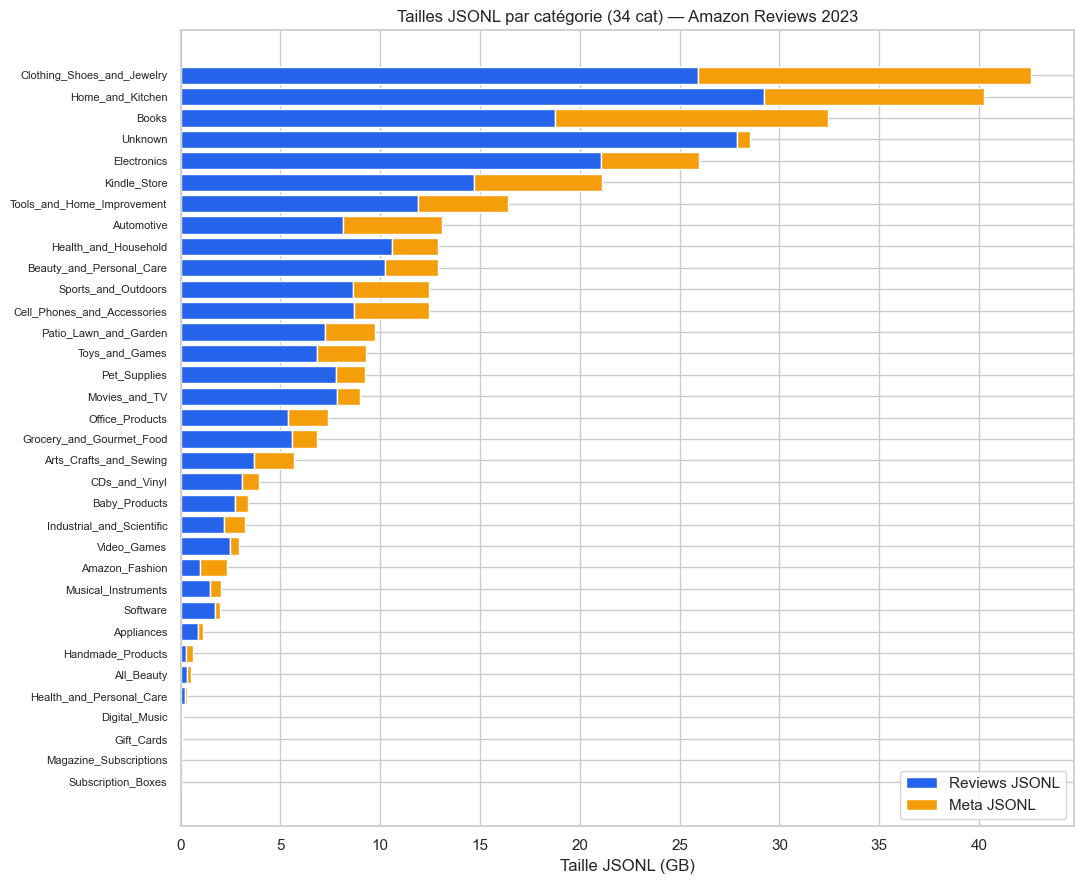

In [12]:
fig, ax = plt.subplots(figsize=(11, 9))
y = range(len(inventory))
ax.barh(y, inventory['review_size_gb'], color='#2563eb', label='Reviews JSONL')
ax.barh(y, inventory['meta_size_gb'], left=inventory['review_size_gb'], color='#f59e0b', label='Meta JSONL')
ax.set_yticks(list(y))
ax.set_yticklabels(inventory['category'], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Taille JSONL (GB)')
ax.set_title(f'Tailles JSONL par catégorie ({len(inventory)} cat) — Amazon Reviews 2023')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIG_DIR / '00a_tailles_par_cat.png', dpi=120)
plt.show()

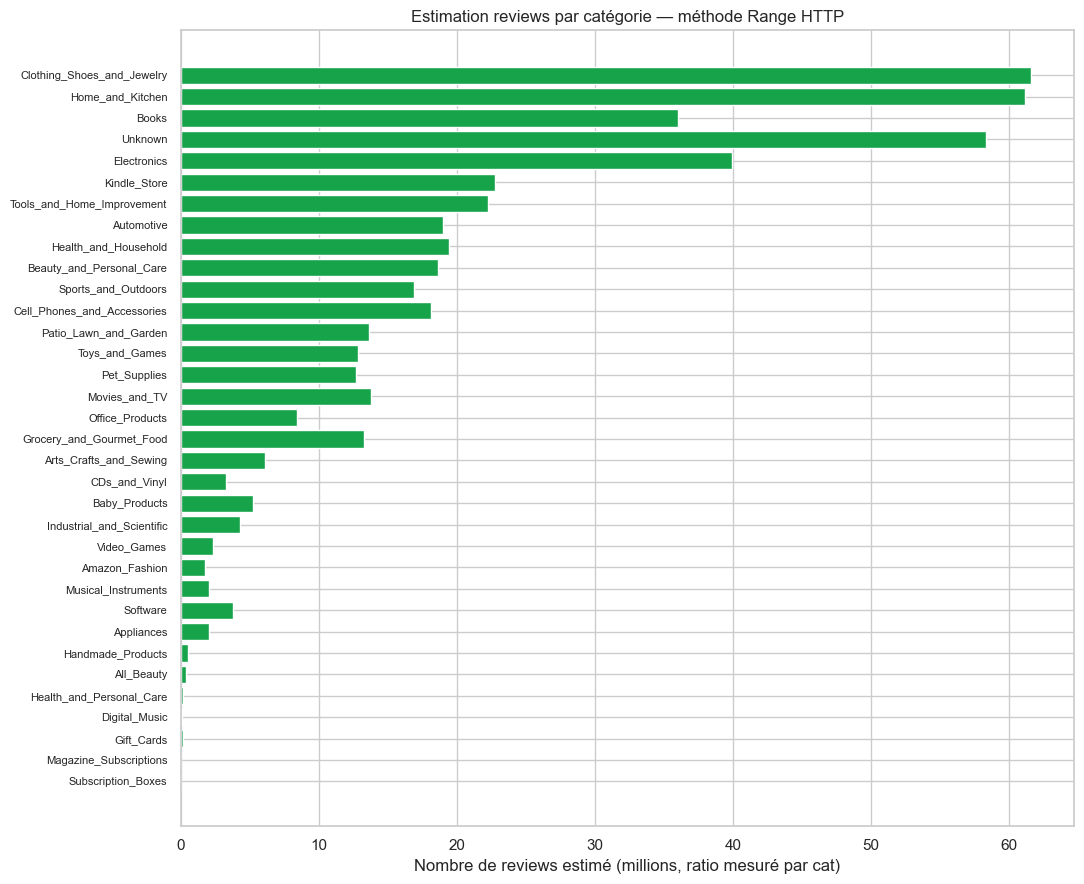

In [13]:
fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(y, inventory['n_reviews_estim_M'], color='#16a34a')
ax.set_yticks(list(y))
ax.set_yticklabels(inventory['category'], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Nombre de reviews estimé (millions, ratio mesuré par cat)')
ax.set_title('Estimation reviews par catégorie — méthode Range HTTP')
plt.tight_layout()
plt.savefig(FIG_DIR / '00b_n_reviews_estim.png', dpi=120)
plt.show()

---

## Étape 8 — Sauvegarder l'inventaire en JSON

L'inventaire est exporté en JSON machine-readable pour qu'il soit consommé par d'autres scripts ultérieurs (par exemple un script de download qui valide que les catégories choisies existent bien dans la liste officielle).

In [14]:
inventory_path = REPORTS_DIR / 'dataset_meta_inventory.json'
payload = {
    'n_categories_official': len(official_categories),
    'method': 'Range HTTP probe (200 KB par fichier .jsonl)',
    'probe_bytes': PROBE_BYTES,
    'totals': {k: float(v) for k, v in summary.items()},
    'inventory': inventory.to_dict(orient='records'),
}
inventory_path.write_text(json.dumps(payload, indent=2, ensure_ascii=False), encoding='utf-8')
print(f'Inventaire sauvé → {inventory_path}')

Inventaire sauvé → d:\Python\rakuten_de_zero\reports\dataset_meta_inventory.json


---

## Étape 9 — Critères de décision pour le périmètre

Le tableau et les graphiques posent les chiffres. La décision se prend en répondant à 5 questions explicites :

### Q1 — Cap volume
Quelle borne supérieure de stockage parquet on accepte ? Plus c'est gros, plus l'audit est représentatif, mais plus le download et l'audit sont longs.
- 0-10 GB : 3-5 cat moyennes
- 10-30 GB : 8-12 cat
- 30-100 GB : 20-30 cat
- pas de cap : 33-34 cat full

### Q2 — Pertinence métier
Quelles catégories sont alignées avec le use case cible (ici : marketplace généraliste pour vendeurs particuliers en France) vs probablement hors-scope ?
- **Bien alignées** : Electronics, Home_and_Kitchen, Clothing_Shoes_and_Jewelry, Toys_and_Games, Beauty_and_Personal_Care, Sports_and_Outdoors, Office_Products, Pet_Supplies, Cell_Phones_and_Accessories, Tools_and_Home_Improvement, Automotive, Patio_Lawn_and_Garden, Health_and_Household, Baby_Products, Musical_Instruments, Video_Games, Movies_and_TV, Industrial_and_Scientific, Arts_Crafts_and_Sewing, Grocery_and_Gourmet_Food
- **Probablement hors-scope** : Books (segment livre dédié), Kindle_Store (numérique), Magazine_Subscriptions (abonnement), Software (numérique), Digital_Music (numérique), CDs_and_Vinyl (collector), Subscription_Boxes (box mensuelle), Gift_Cards (numérique)
- **À investiguer** : `Unknown` — possible fourre-tout sans label exploitable

### Q3 — Hétérogénéité de volume
Pour qu'un benchmark soit représentatif, il faut des catégories **variées en volume** :
- 1-2 "locomotives" (très grosses : > 20 GB) pour mesurer le passage à l'échelle
- 3-4 catégories moyennes (5-15 GB) pour le cas standard
- 1-2 catégories petites (< 1 GB) pour mesurer la robustesse en queue longue

### Q4 — Continuité avec les étapes aval
Le périmètre doit être cohérent avec les phases aval :
- **Cleaning** : merge `parent_asin`, dedup, split — faisable sur n'importe quel sous-ensemble
- **Anti-leakage** : group split par `user_id` ou `parent_asin`
- **Encoders multimodaux** : besoin de catégories avec images riches et descriptions longues
- **Modèle vision-langage fine-tuné** : besoin d'items qui ressemblent à des fiches produit (photos d'objets, pas couvertures de livres ou pochettes de CD)

### Q5 — Coût concret
Pour chaque proposition de périmètre, calculer :
- Volume JSONL à télécharger
- Volume parquet sur disque
- Durée download estimée (selon bande passante)
- Durée audit estimée (selon vitesse polars)

---

## Étape 10 — Calculatrice de scénarios

`evaluate_scope(cats)` renvoie le coût attendu pour une liste de catégories. À utiliser pour comparer plusieurs scénarios avant de trancher.

Les constantes `DOWNLOAD_GB_PER_MIN` et `AUDIT_M_LINES_PER_MIN` sont calibrables selon la bande passante locale et la machine. Les valeurs par défaut sont des ordres de grandeur typiques (fibre + machine de dev récente avec polars lazy).

In [15]:
DOWNLOAD_GB_PER_MIN = 100.0
AUDIT_M_LINES_PER_MIN = 60.0

def evaluate_scope(cats: list[str]) -> pd.Series:
    sub = inventory[inventory['category'].isin(cats)]
    jsonl_gb = sub['total_size_gb'].sum()
    parquet_gb = jsonl_gb * compression_ratio
    n_reviews_M = sub['n_reviews_estim_M'].sum()
    n_items_M = sub['n_meta_estim_M'].sum()
    download_min = jsonl_gb / DOWNLOAD_GB_PER_MIN
    audit_min = n_reviews_M / AUDIT_M_LINES_PER_MIN
    return pd.Series({
        'n_categories': len(cats),
        'JSONL (GB)': jsonl_gb,
        'Parquet attendu (GB)': parquet_gb,
        'Reviews (M)': n_reviews_M,
        'Items (M)': n_items_M,
        'Download estimé (min)': download_min,
        'Audit estimé (min)': audit_min,
    })

# Trois scénarios candidats à titre d'exemple. À ajuster pour le projet en cours.
scenario_minimal = ['Electronics', 'Toys_and_Games', 'All_Beauty']

scenario_metier_aligne = [
    'Clothing_Shoes_and_Jewelry', 'Home_and_Kitchen', 'Electronics',
    'Tools_and_Home_Improvement', 'Beauty_and_Personal_Care',
    'Sports_and_Outdoors', 'Cell_Phones_and_Accessories',
    'Toys_and_Games', 'Office_Products',
    'Patio_Lawn_and_Garden', 'Pet_Supplies', 'Movies_and_TV',
    'Health_and_Household', 'Automotive',
]

scenario_diversite_volume = [
    'Clothing_Shoes_and_Jewelry',
    'Electronics',
    'Home_and_Kitchen',
    'Toys_and_Games',
    'Beauty_and_Personal_Care',
    'Cell_Phones_and_Accessories',
    'Movies_and_TV',
    'Office_Products',
    'Baby_Products',
    'Musical_Instruments',
    'All_Beauty',
    'Magazine_Subscriptions',
]

scenarios_df = pd.DataFrame({
    'Minimal (3 cat)': evaluate_scope(scenario_minimal),
    'Métier-aligné (14 cat)': evaluate_scope(scenario_metier_aligne),
    'Diversité volume (12 cat)': evaluate_scope(scenario_diversite_volume),
    'Tout (34 cat)': evaluate_scope(inventory['category'].tolist()),
})
scenarios_df

,Minimal (3 cat),Métier-aligné (14 cat),Diversité volume (12 cat),Tout (34 cat)
n_categories,3.00,14.00,12.00,34.00
JSONL (GB),35.72,233.71,165.78,350.92
Parquet attendu (GB),8.93,58.43,41.45,87.73
Reviews (M),53.11,338.52,242.18,501.29
Items (M),2.24,21.21,15.24,32.10
Download estimé (min),0.36,2.34,1.66,3.51
Audit estimé (min),0.89,5.64,4.04,8.35


---

## Étape 11 — Inscrire la décision

Une fois le périmètre choisi sur la base de Q1-Q5, il reste à le matérialiser :

1. Définir `CATEGORIES_FINALES` ci-dessous
2. Vérifier le coût avec `evaluate_scope(CATEGORIES_FINALES)`
3. Inscrire la décision avec sa justification critère par critère dans le système de décisions du projet (par exemple `BRAIN/decisions.md` au format ADR)
4. Mettre à jour la constante `CATEGORIES` dans le script de download (`src/data/audit/01_load_full.py`)
5. Lancer `make audit-load` (resume natif → ne re-télécharge que ce qui manque)
6. Lancer `make audit-quality && make audit-dist && make audit-bias`
7. Mettre à jour le rapport `reports/audit_v1_amazon_reviews_2023.md` avec les chiffres mesurés sur le périmètre final

In [ ]:
# CATEGORIES_FINALES = [
#     # Liste à compléter
# ]
#
# evaluate_scope(CATEGORIES_FINALES)

---

## Synthèse

Ce notebook applique la règle **méta-first avant data-first** : les méta-données du dataset (tailles, ratios mesurés par catégorie via Range HTTP) sont collectées avec un coût négligeable (~14 MB, ~30-60 sec) et permettent de choisir un périmètre d'audit sur des chiffres réels plutôt que sur l'intuition. La décision finale s'appuie sur 5 critères explicites (volume, pertinence métier, hétérogénéité, continuité aval, coût) et se matérialise dans une liste `CATEGORIES_FINALES` à propager au script de download.